Fetching data from Hopswork Cloud

In [2]:
import hopsworks
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

# Load your local environment variables
load_dotenv()

# Connect to Hopsworks
print("Connecting to Hopsworks...")
project = hopsworks.login(
    host="eu-west.cloud.hopsworks.ai", # <--- Explicitly routing to Europe
    project="aqi_prediction_project", 
    api_key_value=os.getenv("HOPSWORKS_API_KEY"),
    hostname_verification=False        # <--- Bypassing local Windows SSL blocks
)
fs = project.get_feature_store()

# Download the Feature Group
print("Downloading global_aqi_features...")
fg = fs.get_feature_group(name="global_aqi_features", version=1)
df = fg.read()

# Ensure dates are properly formatted for plotting
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['city', 'date'])

print(f"Data loaded successfully! Shape: {df.shape}")
df.head()

Connecting to Hopsworks...
2026-04-19 14:48:18,583 INFO: Closing external client and cleaning up certificates.
2026-04-19 14:48:18,588 INFO: Initializing external client
2026-04-19 14:48:18,591 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-04-19 14:48:28,423 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/31963
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (44.99s) 
Data loaded successfully! Shape: (8744, 14)


,city,date,pm10,pm2_5,no2,ozone,month,day_of_week,pm2_5_change_rate,pm2_5_rolling_3d,pm2_5_rolling_7d,target_pm2_5_1d,target_pm2_5_2d,target_pm2_5_3d
4329,beijing,2023-04-20 00:00:00+00:00,44.608333,26.391667,38.779167,43.250000,4,3,-37.233333,45.008333,45.008333,21.025000,47.395833,49.758333
2549,beijing,2023-04-21 00:00:00+00:00,34.329167,21.025000,39.250000,41.666667,4,4,-5.366667,23.708333,23.708333,47.395833,49.758333,28.754167
150,beijing,2023-04-22 00:00:00+00:00,68.708333,47.395833,58.995833,25.708333,4,5,26.370833,31.604167,31.604167,49.758333,28.754167,26.570833
735,beijing,2023-04-23 00:00:00+00:00,72.387500,49.758333,66.070833,19.083333,4,6,2.362500,39.393056,36.142708,28.754167,26.570833,33.133333
1281,beijing,2023-04-24 00:00:00+00:00,42.166667,28.754167,46.920833,46.083333,4,0,-21.004167,41.969444,34.665000,26.570833,33.133333,84.820833


## Data and Pattern Analysis

Checking for Outliers


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



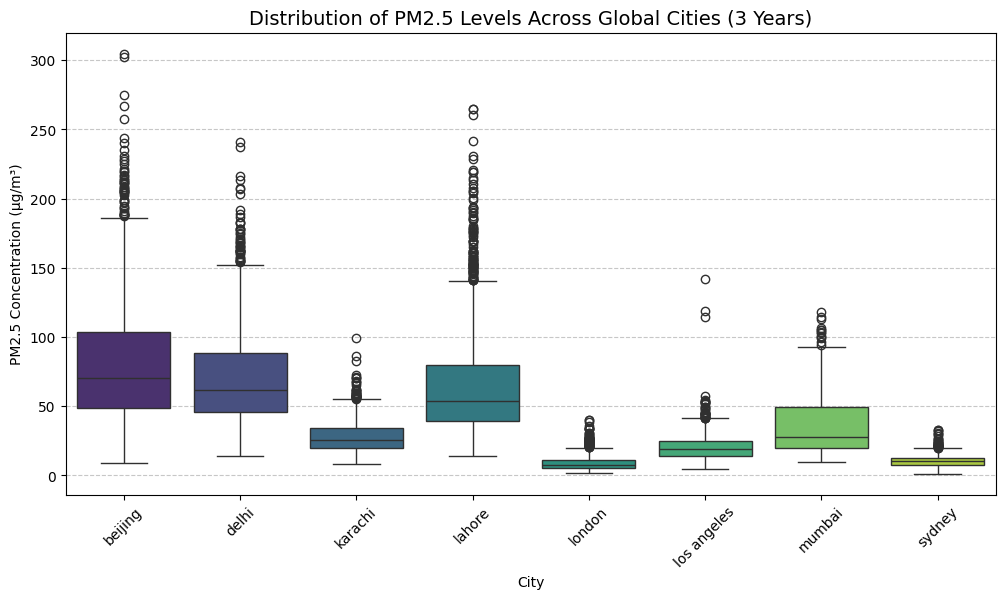

In [3]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='city', y='pm2_5', data=df, palette='viridis')
plt.title('Distribution of PM2.5 Levels Across Global Cities (3 Years)', fontsize=14)
plt.ylabel('PM2.5 Concentration (µg/m³)')
plt.xlabel('City')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Pulling Relevant Historical Data

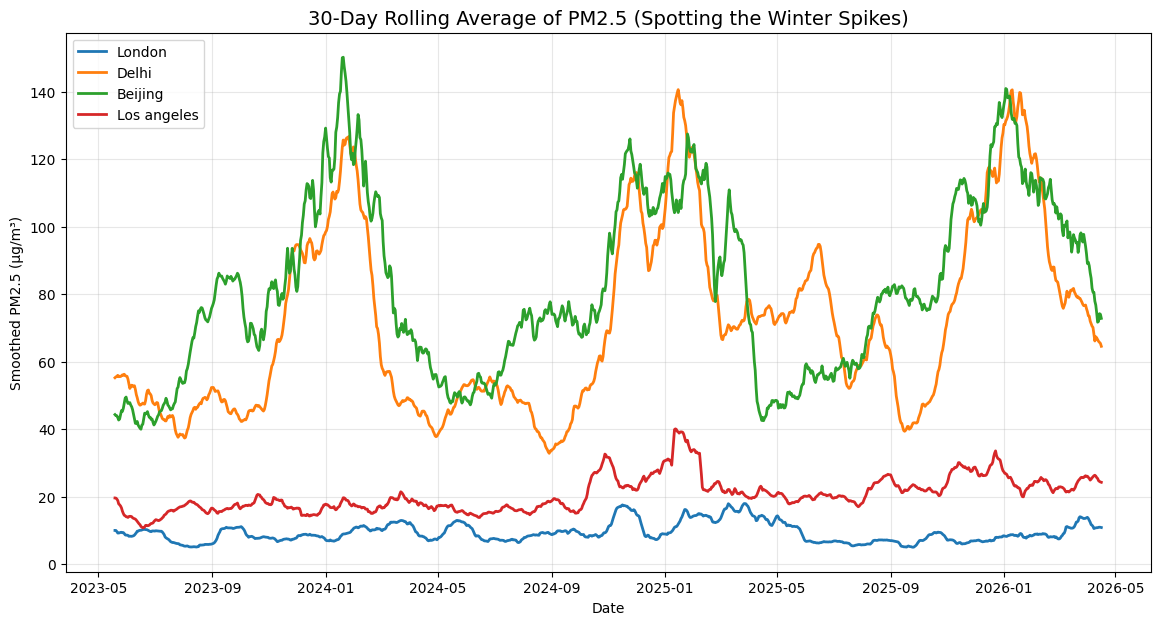

In [4]:
# Select a few distinct cities to compare
cities_to_plot = ['london', 'delhi', 'beijing', 'los angeles']

plt.figure(figsize=(14, 7))

for city in cities_to_plot:
    city_data = df[df['city'] == city].copy()
    # Apply a 30-day rolling average to smooth out the daily noise
    city_data['smoothed_pm25'] = city_data['pm2_5'].rolling(window=30).mean()
    plt.plot(city_data['date'], city_data['smoothed_pm25'], label=city.capitalize(), linewidth=2)

plt.title('30-Day Rolling Average of PM2.5 (Spotting the Winter Spikes)', fontsize=14)
plt.ylabel('Smoothed PM2.5 (µg/m³)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Correlation Heatmap

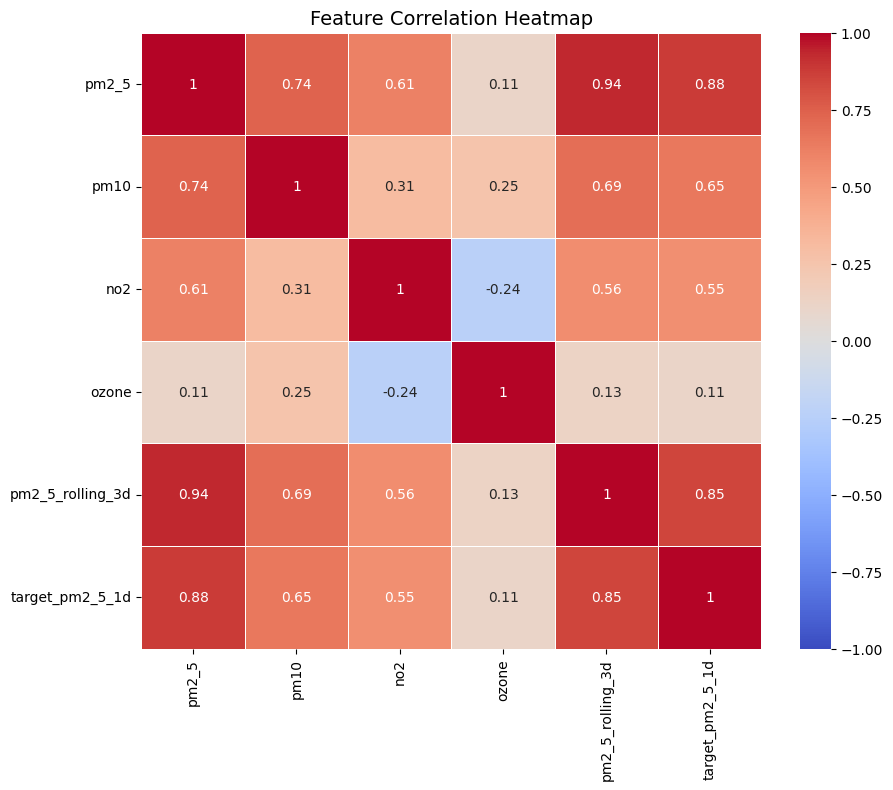

In [6]:
# Select only the numerical weather/pollution columns
cols_to_correlate = ['pm2_5', 'pm10', 'no2', 'ozone', 'pm2_5_rolling_3d', 'target_pm2_5_1d']
corr_matrix = df[cols_to_correlate].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()